In [1]:
%reload_ext autoreload
%autoreload 2
%cd ../

/home/hazzu/Code/thesis


In [3]:
import os

students_id = set()

for card_name in os.listdir("datasets/cards"):
    student_id = card_name.split("_")[0]
    students_id.add(student_id)

for selfie_folder_name in os.listdir("datasets/selfies"):
    student_id = selfie_folder_name.split("_")[0]
    students_id.add(student_id)

for student_id in students_id:
    os.makedirs(f"datasets/image_folder/{student_id}", exist_ok=True)

In [4]:
import os
import shutil
from tqdm import tqdm

for card_name in tqdm(os.listdir("datasets/cards")):
    student_id = card_name.split("_")[0]
    src_path = os.path.join("datasets/cards", card_name)
    dst_path = os.path.join("datasets/image_folder", student_id, card_name)
    shutil.copy(src_path, dst_path)

100%|██████████| 368/368 [00:00<00:00, 987.37it/s] 


In [5]:
import os
import shutil
from tqdm import tqdm

for selfie_folder_name in tqdm(os.listdir("datasets/selfies")):
    student_id = selfie_folder_name.split("_")[0]
    selfie_folder_path = os.path.join("datasets/selfies", selfie_folder_name)

    for selfie_name in os.listdir(selfie_folder_path):
        selfie_path = os.path.join(selfie_folder_path, selfie_name)
        dst_path = os.path.join("datasets/image_folder", student_id, selfie_name)
        shutil.copy(selfie_path, dst_path)

100%|██████████| 141/141 [00:00<00:00, 1246.77it/s]


In [6]:
import os
from os import path as osp

for folder_name in tqdm(os.listdir("datasets/image_folder")):
    folder_path = osp.join("datasets/image_folder", folder_name)

    if len(os.listdir(folder_path)) < 2:
        shutil.rmtree(folder_path)

  0%|          | 0/383 [00:00<?, ?it/s]

100%|██████████| 383/383 [00:00<00:00, 9730.33it/s]


In [7]:
import os
from os import path as osp

for idx, folder_name in tqdm(enumerate(os.listdir("datasets/image_folder"))):
    folder_path = osp.join("datasets/image_folder", folder_name)

    src_path = folder_path
    dst_path = osp.join(
        "datasets/image_folder",
        "0_0_" + ("0" * (7 - len(str(idx))) + str(idx)),
    )

    os.rename(src_path, dst_path)

0it [00:00, ?it/s]

149it [00:00, 39624.10it/s]


In [8]:
import os
from pathlib import Path
from os import path as osp

image_idx = 0
folder_names = os.listdir("datasets/image_folder")
folder_names = sorted(folder_names, key=lambda x: int(x.split("_")[2]))

for folder_name in folder_names:
    folder_path = osp.join("datasets/image_folder", folder_name)

    for image_name in os.listdir(folder_path):
        extension = Path(image_name).suffix

        src_path = osp.join(folder_path, image_name)
        dst_path = osp.join(
            folder_path,
            "0_" + str(image_idx) + extension,
        )

        os.rename(src_path, dst_path)
        image_idx += 1

In [9]:
import cv2, os
from tqdm import tqdm
from lib.face_detector.retinaface import RetinaFaceDetector
from lib.face_recognizer.arcface import ArcFaceRecognizer
from insightface.utils import face_align

retinaface = RetinaFaceDetector()
arcface = ArcFaceRecognizer()

for folder_name in tqdm(os.listdir("datasets/image_folder")):
    folder_path = osp.join("datasets/image_folder", folder_name)

    for image_name in os.listdir(folder_path):
        image_path = osp.join(folder_path, image_name)
        image = cv2.imread(image_path)

        faces = retinaface.detect(image)
        if len(faces) == 0:
            print(f"Face not found in {image_path}")
            continue
        if len(faces) > 1:
            print(f"{len(faces)} faces found in {image_path}")
            continue

        face = faces[0]
        arcface_face = arcface._convert_input_face(face)
        aligned_face = face_align.norm_crop(
            image,
            landmark=arcface_face.kps,
            image_size=arcface._recognizer.input_size[0],
        )

        cv2.imwrite(image_path, aligned_face)

100%|██████████| 149/149 [01:04<00:00,  2.29it/s]


In [11]:
import onnx
from lib.cores.sface import SFace

sface = SFace(modelPath="weights/Backbone_MobileFaceNet.onnx")

[ERROR:0@1958.879] global onnx_importer.cpp:1036 handleNode DNN/ONNX: ERROR during processing node with 3 inputs and 1 outputs: [Conv]:(onnx_node!node_Conv_10) from domain='ai.onnx'


error: OpenCV(4.11.0) /io/opencv/modules/dnn/src/onnx/onnx_importer.cpp:1058: error: (-2:Unspecified error) in function 'handleNode'
> Node [Conv@ai.onnx]:(onnx_node!node_Conv_10) parse error: OpenCV(4.11.0) /io/opencv/modules/dnn/src/layers/layers_common.cpp:106: error: (-5:Bad argument) kernel_size (or kernel_h and kernel_w) not specified in function 'getKernelSize'
> 

In [10]:
import os, cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from lib.face_detector.retinaface import RetinaFaceDetector

SELFIES_PATH = "datasets/selfies"
selfies_name = os.listdir(SELFIES_PATH)

number_images = []
faces_size = []
detector = RetinaFaceDetector()

for selfie_name in tqdm(selfies_name):
    images_path = os.path.join(SELFIES_PATH, selfie_name)
    images_name = os.listdir(images_path)
    number_images.append(len(images_name))

    for image_name in images_name:
        image_path = os.path.join(images_path, image_name)
        image = cv2.imread(image_path)
        faces = detector.detect(image)
        if len(faces) == 0:
            print(f"Face not found in {image_path}")
            continue
        if len(faces) > 1:
            print(f"{len(faces)} faces found in {image_path}")
            continue

        face = faces[0]
        faces_size.append((face.bbox["w"], face.bbox["h"]))

100%|██████████| 140/140 [00:50<00:00,  2.78it/s]


Số lượng sinh viên trong tập ảnh chân dung: 140
Tổng số lượng ảnh trong tập ảnh chân dung: 541


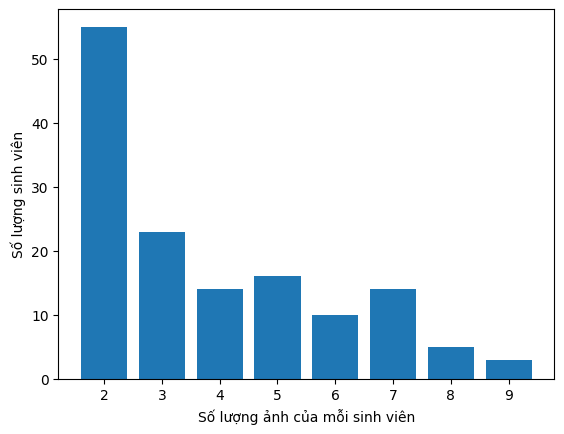

In [14]:
print("Số lượng sinh viên trong tập ảnh chân dung:", len(selfies_name))
print("Tổng số lượng ảnh trong tập ảnh chân dung:", np.sum(number_images))

plt.hist(
    number_images,
    bins=range(2, max(number_images) + 1),
    align="left",
    rwidth=0.8,
)
plt.xticks(range(2, max(number_images)))
plt.xlabel("Số lượng ảnh của mỗi sinh viên")
plt.ylabel("Số lượng sinh viên")
plt.show()

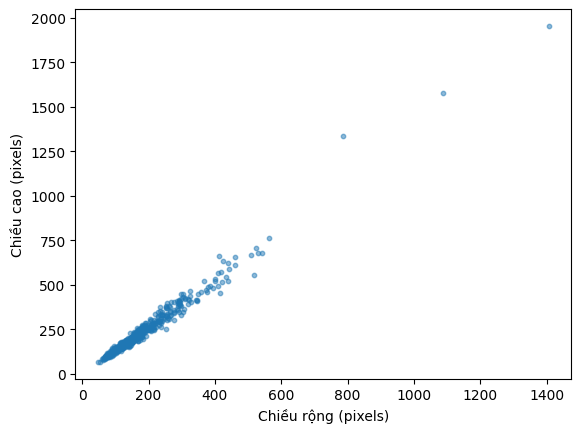

In [12]:
plt.scatter(
    [face[0] for face in faces_size],
    [face[1] for face in faces_size],
    alpha=0.5,
    s=10,
)
plt.xlabel("Chiều rộng (pixels)")
plt.ylabel("Chiều cao (pixels)")
plt.show()

In [ ]:
# import os

# SELFIES_PATH = "datasets/selfies"
# selfies_name = os.listdir(SELFIES_PATH)

# for selfie_name in selfies_name:
#     images_path = os.path.join(SELFIES_PATH, selfie_name)
#     images_name = os.listdir(images_path)

#     if len(images_name) < 2:
#         print(f"Folder {selfie_name} has only one image, removing it.")

In [ ]:
import os
import os.path as osp

identities_name = os.listdir("datasets/ver2/selfies_3")
for identity_name in identities_name:
    identity_path = osp.join("datasets/ver2/selfies_3", identity_name)
    if not osp.isdir(identity_path):
        continue

    # identity_path = identity_path.removeprefix("datasets/ver2/")
    # identity_path = "assets/" + identity_path

    # print("- " + identity_path + "/")
    for image_name in os.listdir(identity_path):
        image_path = osp.join(identity_path, image_name)
        if not osp.isfile(image_path):
            continue

        # image_path = image_path.removeprefix("datasets/ver2/")
        # image_path = "assets/" + image_path

        print('"assets/' + image_path.removeprefix("datasets/ver2/") + '", ')

"assets/selfies_3/21T1020820_HoVietTung/vlcsnap-2024122500006.png", 
"assets/selfies_3/21T1020820_HoVietTung/vlcsnap-2024122500005.png", 
"assets/selfies_3/21T1020820_HoVietTung/vlcsnap-2024122500004.png", 
"assets/selfies_3/21T1020820_HoVietTung/vlcsnap-2024122500002.png", 
"assets/selfies_3/21T1020820_HoVietTung/vlcsnap-2024122500001.png", 
"assets/selfies_3/24T1020459_TranDangNhatThanh/vlcsnap-00062.png", 
"assets/selfies_3/24T1020459_TranDangNhatThanh/vlcsnap-00061.png", 
"assets/selfies_3/24T1020459_TranDangNhatThanh/vlcsnap-2024122500087.png", 
"assets/selfies_3/24T1020459_TranDangNhatThanh/vlcsnap-2024122500086.png", 
"assets/selfies_3/24T1020459_TranDangNhatThanh/vlcsnap-2024122500088.png", 
"assets/selfies_3/24T1020459_TranDangNhatThanh/vlcsnap-2024122500085.png", 
"assets/selfies_3/24T1020202_NguyenQuangHuy/vlcsnap-2024122500029.png", 
"assets/selfies_3/24T1020202_NguyenQuangHuy/vlcsnap-00017.png", 
"assets/selfies_3/24T1020202_NguyenQuangHuy/vlcsnap-00016.png", 
"assets/self

In [16]:
results = {
    "SFace (Baseline)": "results/inference-time/SFace (Baseline).txt",
    "SFace + KD (SFace-OpenCV)": "results/inference-time/SFace + KD (SFace-OpenCV).txt",
    "SFace + KD (SFace-OpenCV) Finetuning": "results/inference-time/SFace + KD (SFace-OpenCV) Finetuning.txt",
    "SFace + KD (ArcFace)": "results/inference-time/SFace + KD (ArcFace).txt",
}

for name, path in results.items():
    with open(path, "r") as f:
        line = f.readline()
        latencies = line.split(", ")
        latencies = [float(latency) for latency in latencies if latency.strip()]
        results[name] = {
            "mean": sum(latencies) / len(latencies),
            "min": min(latencies),
            "max": max(latencies),
            "std": (
                sum((x - sum(latencies) / len(latencies)) ** 2 for x in latencies)
                / len(latencies)
            )
            ** 0.5,
        }

print(results)

{'SFace (Baseline)': {'mean': 24.677248677248677, 'min': 17.0, 'max': 59.0, 'std': 4.661738990939015}, 'SFace + KD (SFace-OpenCV)': {'mean': 24.703703703703702, 'min': 17.0, 'max': 43.0, 'std': 3.5585855695941677}, 'SFace + KD (SFace-OpenCV) Finetuning': {'mean': 25.126984126984127, 'min': 17.0, 'max': 47.0, 'std': 3.6853437600009142}, 'SFace + KD (ArcFace)': {'mean': 25.984126984126984, 'min': 18.0, 'max': 48.0, 'std': 3.984727710355373}}
